In [1]:
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader,TensorDataset

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)

#device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Torch version : {torch.__version__}")
print(f"Device        : {device}")



Torch version : 2.12.0+cpu
Device        : cpu


In [2]:
import torchvision
import torchvision.transforms as transforms

# Transformation : PIL Image -> Tensor -> Normalisation
transform = transforms.Compose([
    transforms.ToTensor(),           # 0-255 → 0.0-1.0
    transforms.Normalize((0.1307,), (0.3081,))  # mean/std MNIST
])

# Telecharger MNIST
train_dataset = torchvision.datasets.MNIST(
    root='../data', train=True,
    download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root='../data', train=False,
    download=True, transform=transform
)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size = 128,
    shuffle = True,
    num_workers = 0 
)

test_loader = DataLoader(
    test_dataset,
    batch_size = 128,
    shuffle = False,
    num_workers = 0
)

print(f"Train : {len(train_dataset):,} images")
print(f"Test  : {len(test_dataset):,} images")
print(f"Batches train : {len(train_loader)}")
print(f"Shape batch   : {next(iter(train_loader))[0].shape}")


Train : 60,000 images
Test  : 10,000 images
Batches train : 469
Shape batch   : torch.Size([128, 1, 28, 28])


In [3]:
# Architecture MLP avec pytorch

class MLP(nn.Module):
    """
    MLP identique au modele Keras :
    784 → 512 → 256 → 128 → 10

    Meme architecture pour comparer les resultats.
    """

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # Flatten (batch,1,28,28) -> (batch,784)
            nn.Flatten(),

            # Couche 1
            nn.Linear(784,512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Couche 2
            nn.Linear(512,256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Couche 3
            nn.Linear(256,128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            
            # Sortie
            nn.Linear(128,10)
            # Pas de softmax à ce niveau !            
        )
    def forward(self,x):
        return self.net(x)

# Instancier
model_pt = MLP().to(device)

# Compter les parametres
total_params = sum(p.numel() for p in model_pt.parameters())
print(f"Architecture : 784 → 512 → 256 → 128 → 10")
print(f"Parametres   : {total_params:,}")
print()
print(model_pt)

Architecture : 784 → 512 → 256 → 128 → 10
Parametres   : 569,226

MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=512, out_features=256, bias=True)
    (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=256, out_features=128, bias=True)
    (10): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): ReLU()
    (12): Dropout(p=0.3, inplace=False)
    (13): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [4]:
# Optimiseur et perte
optimizer = optim.Adam(model_pt.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# Boucle d'entrainement
N_EPOCHS  = 50
best_acc  = 0.0
patience  = 10
no_improve = 0
history   = {'train_loss':[], 'val_acc':[]}

print("Debut entrainement MLP PyTorch...")
print("="*50)

for epoch in range(1, N_EPOCHS+1):

    # ── TRAIN ────────────────────────────────────────────
    model_pt.train()
    train_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_pt(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ── VALIDATION (sur test set) ─────────────────────
    model_pt.eval()
    correct = total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_pt(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

    val_acc = correct / total
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc)

    # Scheduler
    scheduler.step(train_loss)

    # Afficher progression
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{N_EPOCHS} | "
              f"Loss: {train_loss:.4f} | "
              f"Acc: {val_acc*100:.2f}%")

    # Early Stopping manuel
    if val_acc > best_acc:
        best_acc   = val_acc
        no_improve = 0
        torch.save(model_pt.state_dict(), '../models/mlp_pytorch_mnist.pt')
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"\nEarly Stopping a l'epoch {epoch}")
            break

print(f"\n Entrainement termine !")
print(f"   Meilleure accuracy : {best_acc*100:.2f}%")

Debut entrainement MLP PyTorch...
Epoch   1/50 | Loss: 0.3036 | Acc: 96.81%
Epoch   5/50 | Loss: 0.0769 | Acc: 98.07%
Epoch  10/50 | Loss: 0.0461 | Acc: 98.37%
Epoch  15/50 | Loss: 0.0339 | Acc: 98.45%
Epoch  20/50 | Loss: 0.0258 | Acc: 98.58%

Early Stopping a l'epoch 21

 Entrainement termine !
   Meilleure accuracy : 98.59%


COMPARAISON FINALE — Keras vs PyTorch
  MLP Keras   : 98.98% accuracy | 571,018 params
  MLP PyTorch : 98.59% accuracy | 569,226 params

CONCLUSION :
  -> Meme architecture = resultats comparables
  -> La difference est dans la SYNTAXE, pas les performances
  -> Keras : plus concis (Sequential)
  -> PyTorch : plus explicite (Module + boucle manuelle)



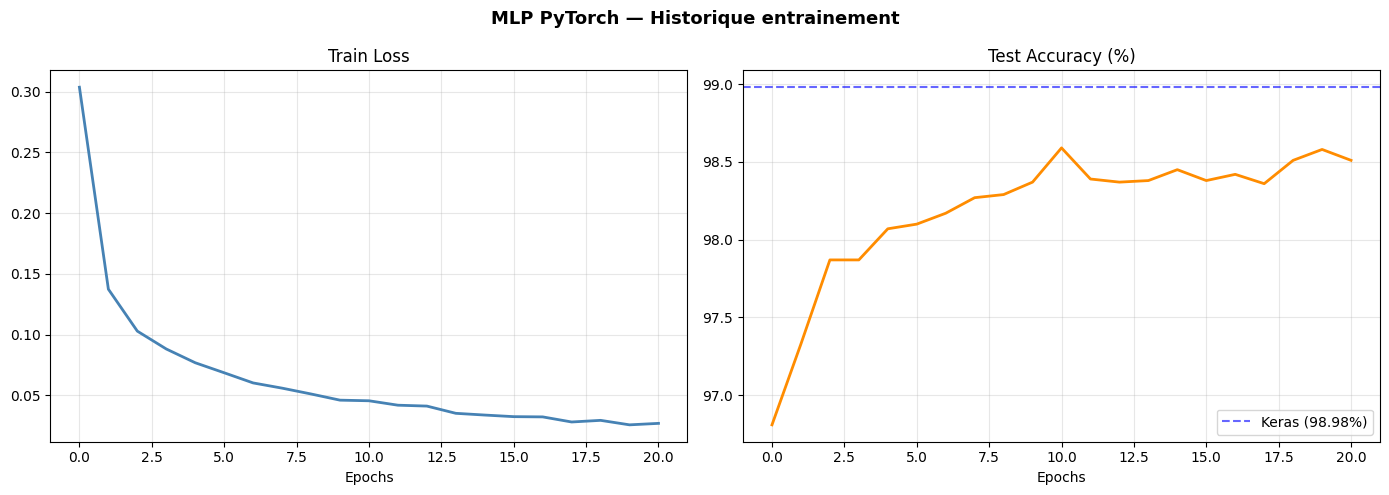

In [7]:
# Charger le meilleur modele sauvegarde
model_pt.load_state_dict(
    torch.load('../models/mlp_pytorch_mnist.pt', map_location=device)
)
model_pt.eval()

# Collecter toutes les predictions
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model_pt(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

pytorch_acc = (all_preds == all_labels).mean()

print("="*55)
print("COMPARAISON FINALE — Keras vs PyTorch")
print("="*55)
print(f"  MLP Keras   : 98.98% accuracy | 571,018 params")
print(f"  MLP PyTorch : {pytorch_acc*100:.2f}% accuracy | {total_params:,} params")
print()
print("CONCLUSION :")
print("  -> Meme architecture = resultats comparables")
print("  -> La difference est dans la SYNTAXE, pas les performances")
print("  -> Keras : plus concis (Sequential)")
print("  -> PyTorch : plus explicite (Module + boucle manuelle)")
print()

# Courbes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("MLP PyTorch — Historique entrainement",
             fontsize=13, fontweight='bold')

axes[0].plot(history['train_loss'], color='steelblue', lw=2)
axes[0].set_title("Train Loss")
axes[0].set_xlabel("Epochs")
axes[0].grid(True, alpha=0.3)

axes[1].plot([a*100 for a in history['val_acc']],
             color='darkorange', lw=2)
axes[1].set_title("Test Accuracy (%)")
axes[1].set_xlabel("Epochs")
axes[1].axhline(y=98.98, color='blue', linestyle='--',
                alpha=0.6, label='Keras (98.98%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../assets/mlp_pytorch_curves.png', dpi=150, bbox_inches='tight')
plt.show()